# **Analysis of Populist Groups**

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
# Import dataset
ep = pd.read_csv('../data/ep_speeches_analysis.csv')

In [10]:
# Import dataset on populist ep party groups 
populist_groups = pd.read_excel('../data/ep_populist_party_data.xlsx')
populist_groups.head()

,country,year,party,party_name_short,party_eng,party_year,ep_political_group,vote_share,seats,total_group_seats,total_ep_seats,rightwing,radicalright,leftwing,valence,party_entry,group_change
0,Great Britain,1999,United Kingdom Independence Party,UKIP,United Kingdom Independence Party,UKIP_1999,EDD,7.0,3,18,788,1,0,0,0,1,0
1,Italy,1999,Forza Italia / Il Popolo della Libertà,FI / PdL,Forza Italia – The People of Freedom,FI / PdL_1999,EPP,25.2,22,295,788,1,0,0,0,1,0
2,Germany,1999,Partei des Demokratischen Sozialismus / Die Linke,PDS/LINKE,PDS / The Left,PDS/LINKE_1999,GUE/NGL,5.8,6,55,788,0,0,1,0,1,0
3,Greece,1999,Dimokratiko Koinoniko Kinima,DIKKI,Democratic Social Movement,DIKKI_1999,GUE/NGL,6.9,2,55,788,0,0,1,0,1,0
4,Netherlands,1999,Socialistiese Partij,SP,Socialist Party,SP_1999,GUE/NGL,5.0,1,55,788,0,0,1,0,1,0


In [11]:
populist_groups['ep_political_group'].unique()

array(['EDD', 'EPP', 'GUE/NGL', 'NI', 'UEN', 'ALDE', 'IND/DEM', 'PSE',
       'ECR', 'EFD', 'EFDD', 'ENF', 'ID', 'Renew', 'The Left'],
      dtype=object)

In [12]:
populist_groups['ep_political_group'] = populist_groups['ep_political_group'].replace({
    'PSE': 'S&D',
    'GUE/NGL': 'The Left',
    'ALDE': 'Renew',
    'EDD': 'IND/DEM',
    'EFD': 'EFDD',
    'ENF': 'ID',
})

In [13]:
# Change years to legislative periods
populist_groups['year'] = populist_groups['year'].replace({
    1999 : '5',
    2004 : '6',
    2009 : '7',
    2014 : '8',
    2019 : '9',
})

# Rename year to period column
populist_groups.rename(columns={'year': 'period'}, inplace=True)

populist_groups.head()

,country,period,party,party_name_short,party_eng,party_year,ep_political_group,vote_share,seats,total_group_seats,total_ep_seats,rightwing,radicalright,leftwing,valence,party_entry,group_change
0,Great Britain,5,United Kingdom Independence Party,UKIP,United Kingdom Independence Party,UKIP_1999,IND/DEM,7.0,3,18,788,1,0,0,0,1,0
1,Italy,5,Forza Italia / Il Popolo della Libertà,FI / PdL,Forza Italia – The People of Freedom,FI / PdL_1999,EPP,25.2,22,295,788,1,0,0,0,1,0
2,Germany,5,Partei des Demokratischen Sozialismus / Die Linke,PDS/LINKE,PDS / The Left,PDS/LINKE_1999,The Left,5.8,6,55,788,0,0,1,0,1,0
3,Greece,5,Dimokratiko Koinoniko Kinima,DIKKI,Democratic Social Movement,DIKKI_1999,The Left,6.9,2,55,788,0,0,1,0,1,0
4,Netherlands,5,Socialistiese Partij,SP,Socialist Party,SP_1999,The Left,5.0,1,55,788,0,0,1,0,1,0


### Metrics on Populist Parties in EP

In [14]:
# Populist parties per legislative period
populist_groups['period'].value_counts().sort_index()

period
5    10
6    18
7    25
8    25
9    32
Name: count, dtype: int64

In [15]:
# Share of populist parties per legislative period

# Total populist seats per period
populist_ep_seats = populist_groups.groupby('period')['seats'].sum().reset_index(name='populist_ep_seats')

# Total EP seats per period (assuming total_ep_seats is constant per period, take the first/max value)
total_ep_seats = populist_groups.groupby('period')['total_ep_seats'].first().reset_index()

# Merge and calculate share
seats_share = pd.merge(populist_ep_seats, total_ep_seats, on='period')
seats_share['populist_ep_share'] = (seats_share['populist_ep_seats'] / seats_share['total_ep_seats']) * 100

print(seats_share)

  period  populist_ep_seats  total_ep_seats  populist_ep_share
0      5                 51             788           6.472081
1      6                 94             785          11.974522
2      7                131             764          17.146597
3      8                174             749          23.230975
4      9                225             703          32.005690


In [16]:
# Share of populist national parties within the EP political groups

# Total populist seats per group per period
populist_seats_group = populist_groups.groupby(['period', 'ep_political_group'])['seats'].sum().reset_index(name='populist_group_seats')

# Total seats per group per period
total_group_seats = populist_groups.groupby(['period', 'ep_political_group'])['total_group_seats'].first().reset_index()

# Merge and calculate share
seats_share_group = pd.merge(populist_seats_group, total_group_seats, on=['period', 'ep_political_group'])
seats_share_group['populist_share_of_group'] = (seats_share_group['populist_group_seats'] / seats_share_group['total_group_seats']) * 100

seats_share_group.head(20)

,period,ep_political_group,populist_group_seats,total_group_seats,populist_share_of_group
0,5,EPP,22,295,7.457627
1,5,IND/DEM,3,18,16.666667
2,5,NI,16,44,36.363636
3,5,The Left,9,55,16.363636
4,5,UEN,1,30,3.333333
5,6,EPP,14,288,4.861111
6,6,IND/DEM,23,22,104.545455
7,6,NI,13,30,43.333333
8,6,Renew,5,67,7.462687
9,6,S&D,3,218,1.376147


In [17]:
mean_share_per_group = seats_share_group.groupby('ep_political_group')['populist_share_of_group'].mean().reset_index()
print(mean_share_per_group)

  ep_political_group  populist_share_of_group
0                ECR                75.967587
1               EFDD                99.577573
2                EPP                10.502313
3                 ID                52.097506
4            IND/DEM                60.606061
5                 NI                75.262626
6              Renew                 5.958173
7                S&D                 1.376147
8           The Left                33.465480
9                UEN                33.484848


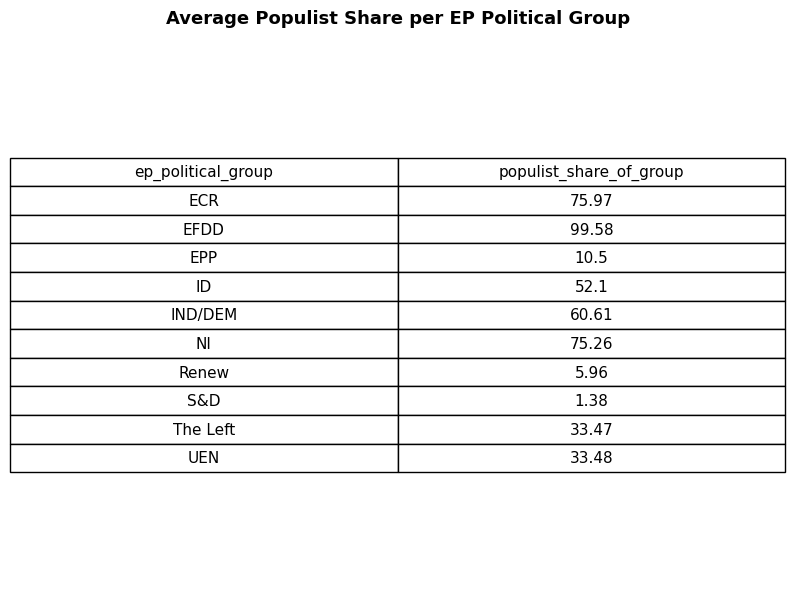

In [18]:
mean_share_per_group = mean_share_per_group.round(2)

fig, ax = plt.subplots(figsize=(8, len(mean_share_per_group) * 0.5 + 1))
ax.axis('off')
table = ax.table(
    cellText=mean_share_per_group.values,
    colLabels=mean_share_per_group.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)

plt.title('Average Populist Share per EP Political Group', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
#plt.savefig('../outputs/tables/mean_populist_share_per_group.png', dpi=150, bbox_inches='tight')
plt.show()

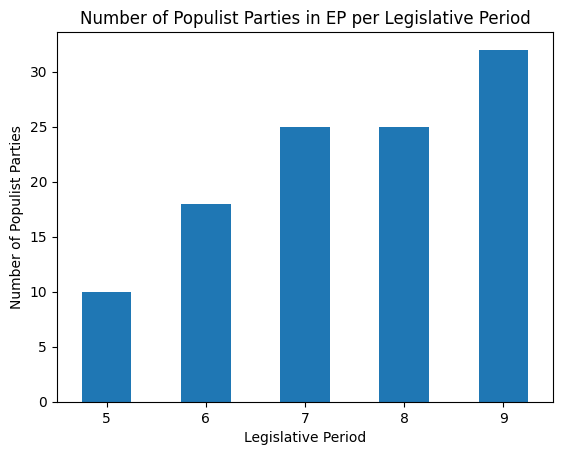

In [19]:
populist_groups['period'].value_counts().sort_index().plot(kind='bar')
plt.title('Number of Populist Parties in EP per Legislative Period')
plt.xlabel('Legislative Period')
plt.ylabel('Number of Populist Parties')
plt.xticks(rotation=0)
plt.show()



In [20]:
# Populism per group 
counts = populist_groups.groupby('ep_political_group')['valence'].value_counts().reset_index()
print(counts)

   ep_political_group  valence  count
0                 ECR        0     18
1                 ECR        1      1
2                EFDD        0      9
3                EFDD        1      1
4                 EPP        0     11
5                 EPP        1      4
6                  ID        0     10
7             IND/DEM        0      4
8                  NI        0     20
9                  NI        1      4
10              Renew        1      5
11                S&D        0      1
12           The Left        0     16
13                UEN        0      6


In [21]:
# Populist parties per EP party group 
populist_groups['ep_political_group'].value_counts()

ep_political_group
NI          24
ECR         19
The Left    16
EPP         15
EFDD        10
ID          10
UEN          6
Renew        5
IND/DEM      4
S&D          1
Name: count, dtype: int64

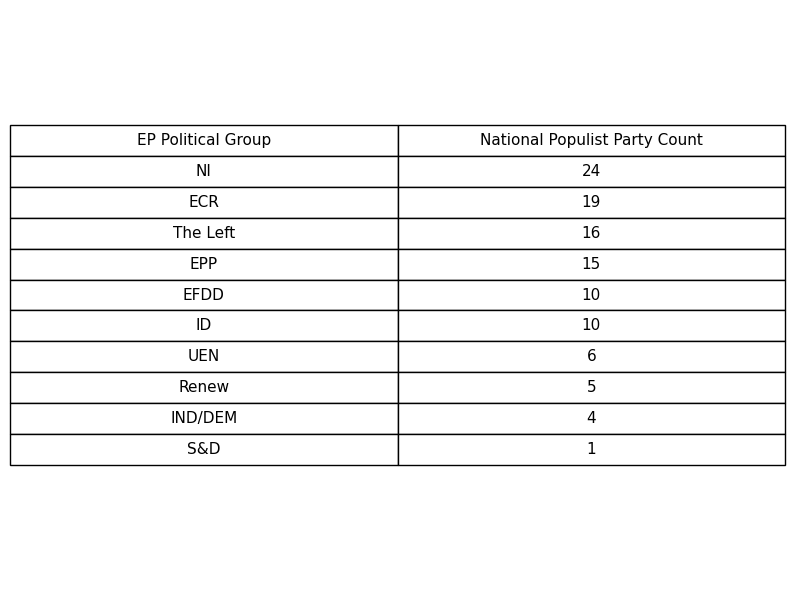

In [22]:
counts = populist_groups['ep_political_group'].value_counts().reset_index()
counts.columns = ['EP Political Group', 'National Populist Party Count']

fig, ax = plt.subplots(figsize=(8, len(counts) * 0.5 + 1))
ax.axis('off')
table = ax.table(cellText=counts.values,
                 colLabels=counts.columns,
                 cellLoc='center',
                 loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)

#plt.title('Populist Parties per EP Political Group', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
#plt.savefig('../outputs/tables/populist_parties_per_group.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Calculate
members_per_period = populist_groups.groupby(['period', 'ep_political_group'])['party'].nunique().reset_index(name='members')
print(members_per_period)

   period ep_political_group  members
0       5                EPP        1
1       5            IND/DEM        1
2       5                 NI        4
3       5           The Left        3
4       5                UEN        1
5       6                EPP        2
6       6            IND/DEM        3
7       6                 NI        4
8       6              Renew        1
9       6                S&D        1
10      6           The Left        2
11      6                UEN        5
12      7                ECR        3
13      7               EFDD        7
14      7                EPP        3
15      7                 NI        9
16      7              Renew        1
17      7           The Left        2
18      8                ECR        7
19      8               EFDD        3
20      8                EPP        4
21      8                 ID        4
22      8                 NI        2
23      8              Renew        1
24      8           The Left        4
25      9   

In [24]:
# Define party group order and color palette for plots
group_order = [
    'The Left', 'S&D', 'Greens/EFA', 'Renew', 'EPP', 'IND/DEM', 'UEN', 'ECR', 'EFDD', 'ID', 'NI'
]

In [25]:
group_palette = {
    'The Left':    '#820510',  # dark red - far left
    'S&D':        '#F21818',  # red - social democrats
    'Greens/EFA': '#08730C',  # green
    'Renew':       '#199BF7',  # bright blue - liberals
    'EPP':        '#01548F',  # dark blue - centre-right
    'IND/DEM':    '#88B4CF',  # light blue - eurosceptics
    'UEN':        '#545380',  # purple grey - eurosceptics
    'ECR':        '#116899',  # dark blue - conservatives
    'EFDD':        '#04AEBF',  # teal - eurosceptics 
    'ID':        '#036BAB',  # blue - far right 
    'NI':         '#808080',  # grey - non-attached
}

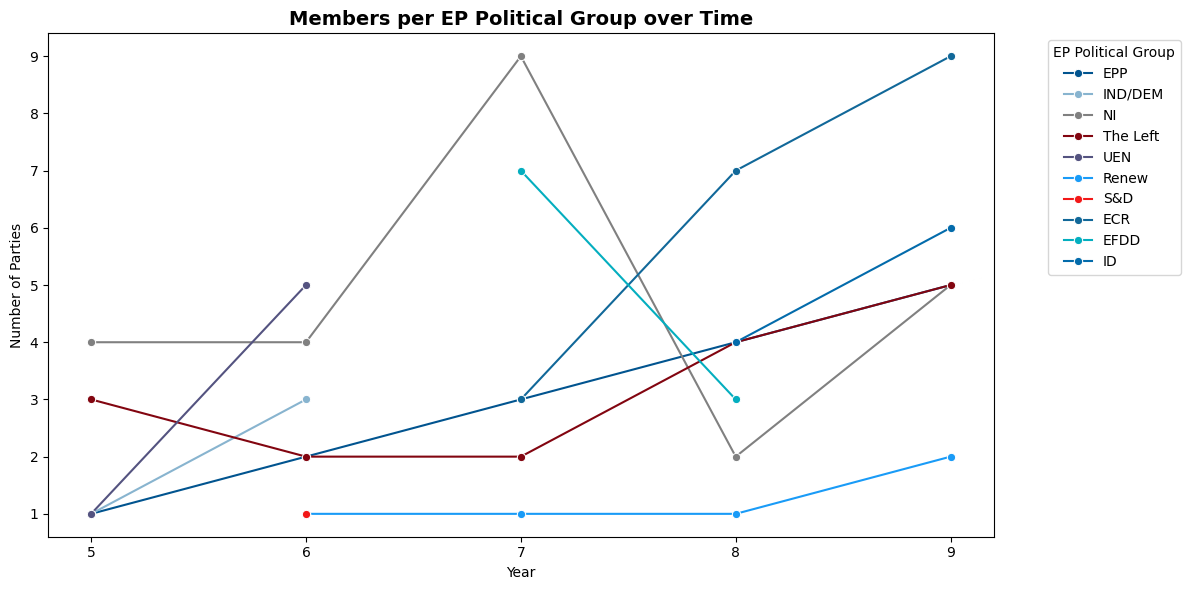

In [ ]:
# Visualise
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=members_per_period,
    x='period',
    y='members',
    hue='ep_political_group',
    marker='o',
    palette=group_palette,
)

plt.title('Members per EP Political Group over Time', fontsize=14, fontweight='bold')
plt.ylabel('Number of Parties')
plt.xlabel('Year')
plt.legend(title='EP Political Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
#plt.savefig('../outputs/graphs/members_per_group_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
# Total seats of populist parties per period
seats_per_group = populist_groups.groupby('period')['seats'].sum().reset_index(name='total_seats')
print(seats_per_group)

  period  total_seats
0      5           51
1      6           94
2      7          131
3      8          174
4      9          225


In [32]:
# Number of seats in EP per populist party group over all years
seats_per_group = populist_groups.groupby('ep_political_group')['seats'].sum().reset_index(name='total_seats')
print(seats_per_group)

  ep_political_group  total_seats
0                ECR          151
1               EFDD           73
2                EPP          121
3                 ID           46
4            IND/DEM           26
5                 NI          136
6              Renew           19
7                S&D            3
8           The Left           71
9                UEN           29


In [33]:
# Total seats and number of periods present per group
seats_per_group = populist_groups.groupby('ep_political_group').agg(
    total_seats=('seats', 'sum'),
    legislations_present=('period', 'nunique')
).reset_index()

seats_per_group['avg_seats_per_period'] = seats_per_group['total_seats'] / seats_per_group['legislations_present']

print(seats_per_group)

  ep_political_group  total_seats  legislations_present  avg_seats_per_period
0                ECR          151                     3             50.333333
1               EFDD           73                     2             36.500000
2                EPP          121                     5             24.200000
3                 ID           46                     2             23.000000
4            IND/DEM           26                     2             13.000000
5                 NI          136                     5             27.200000
6              Renew           19                     4              4.750000
7                S&D            3                     1              3.000000
8           The Left           71                     5             14.200000
9                UEN           29                     2             14.500000


In [34]:
# Number of seats in EP per populist party group per period
seats_per_group = populist_groups.groupby(['period', 'ep_political_group'])['seats'].sum().reset_index(name='total_seats')
print(seats_per_group)

   period ep_political_group  total_seats
0       5                EPP           22
1       5            IND/DEM            3
2       5                 NI           16
3       5           The Left            9
4       5                UEN            1
5       6                EPP           14
6       6            IND/DEM           23
7       6                 NI           13
8       6              Renew            5
9       6                S&D            3
10      6           The Left            8
11      6                UEN           28
12      7                ECR           45
13      7               EFDD           30
14      7                EPP           21
15      7                 NI           24
16      7              Renew            2
17      7           The Left            9
18      8                ECR           31
19      8               EFDD           43
20      8                EPP           34
21      8                 ID           14
22      8                 NI      

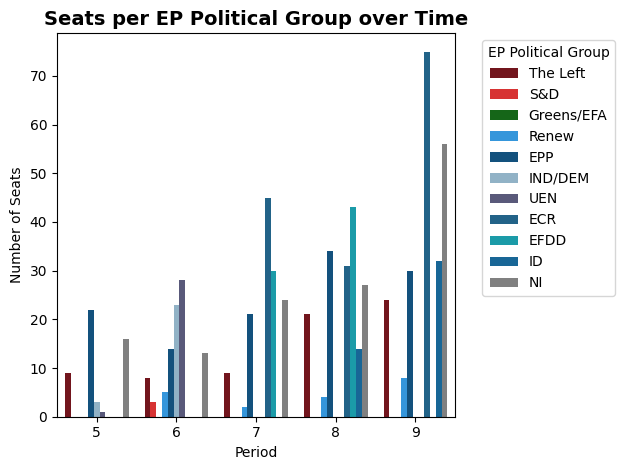

In [36]:
sns.barplot(
    data=seats_per_group,
    x='period',
    y='total_seats',
    hue='ep_political_group',
    palette=group_palette, 
    hue_order=group_order,
)

plt.title('Seats per EP Political Group over Time', fontsize=14, fontweight='bold')
plt.ylabel('Number of Seats')
plt.xlabel('Period')
plt.legend(title='EP Political Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../outputs/graphs/seats_per_group_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

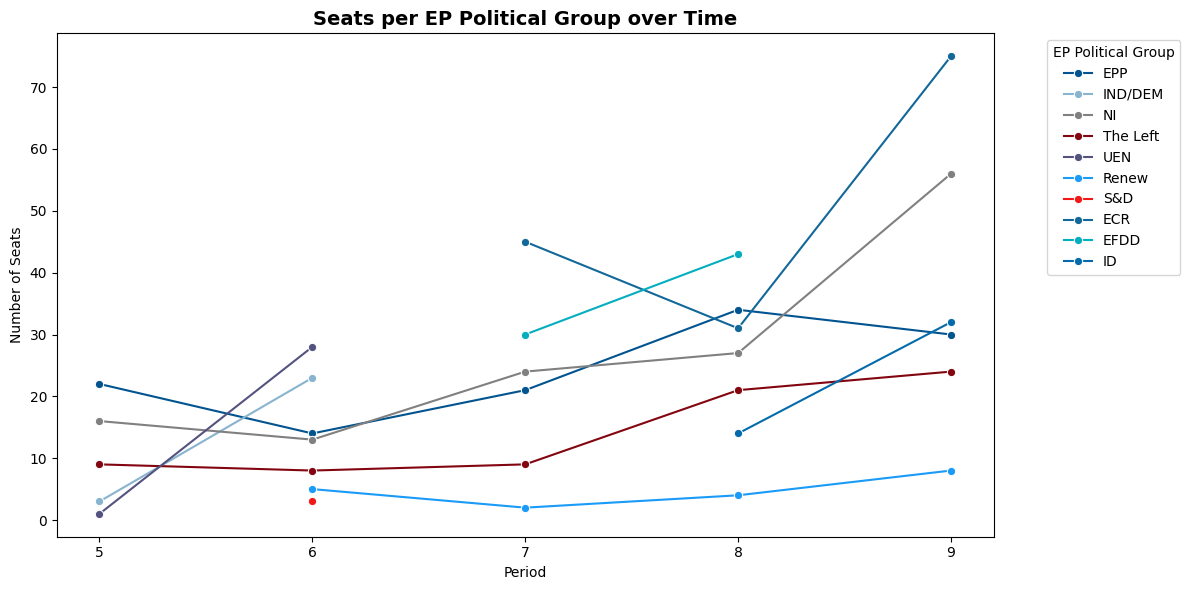

In [37]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=seats_per_group,
    x='period',
    y='total_seats',
    hue='ep_political_group',
    marker='o',
    palette=group_palette,
)

plt.title('Seats per EP Political Group over Time', fontsize=14, fontweight='bold')
plt.ylabel('Number of Seats')
plt.xlabel('Period')
plt.legend(title='EP Political Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
#plt.savefig('../outputs/graphs/members_per_group_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

## **Dataset Merge**

In [26]:
print(seats_share)

  period  populist_ep_seats  total_ep_seats  populist_ep_share
0      5                 51             788           6.472081
1      6                 94             785          11.974522
2      7                131             764          17.146597
3      8                174             749          23.230975
4      9                225             703          32.005690


In [27]:
print(seats_share_group)

   period ep_political_group  populist_group_seats  total_group_seats  \
0       5                EPP                    22                295   
1       5            IND/DEM                     3                 18   
2       5                 NI                    16                 44   
3       5           The Left                     9                 55   
4       5                UEN                     1                 30   
5       6                EPP                    14                288   
6       6            IND/DEM                    23                 22   
7       6                 NI                    13                 30   
8       6              Renew                     5                 67   
9       6                S&D                     3                218   
10      6           The Left                     8                 40   
11      6                UEN                    28                 44   
12      7                ECR                    45 

In [28]:
# Rename ep_political_group to party column
seats_share_group.rename(columns={'ep_political_group': 'party'}, inplace=True)
seats_share_group.head()

,period,party,populist_group_seats,total_group_seats,populist_share_of_group
0,5,EPP,22,295,7.457627
1,5,IND/DEM,3,18,16.666667
2,5,NI,16,44,36.363636
3,5,The Left,9,55,16.363636
4,5,UEN,1,30,3.333333


In [29]:
# Convert to integers
seats_share['period'] = seats_share['period'].astype(int)
seats_share_group['period'] = seats_share_group['period'].astype(int)

In [30]:
pop = pd.merge(seats_share_group, seats_share, on='period', how='outer')
pop.head(20)

,period,party,populist_group_seats,total_group_seats,populist_share_of_group,populist_ep_seats,total_ep_seats,populist_ep_share
0,5,EPP,22,295,7.457627,51,788,6.472081
1,5,IND/DEM,3,18,16.666667,51,788,6.472081
2,5,NI,16,44,36.363636,51,788,6.472081
3,5,The Left,9,55,16.363636,51,788,6.472081
4,5,UEN,1,30,3.333333,51,788,6.472081
5,6,EPP,14,288,4.861111,94,785,11.974522
6,6,IND/DEM,23,22,104.545455,94,785,11.974522
7,6,NI,13,30,43.333333,94,785,11.974522
8,6,Renew,5,67,7.462687,94,785,11.974522
9,6,S&D,3,218,1.376147,94,785,11.974522


In [31]:
pop.to_csv('../data/ep_populist_party_seat_data.csv', index=False)

In [32]:
ep.head()

,unique_id,speech_id,sentence_id,speaker,party,date,agenda,period,year,legislative_year,sentence,prob_non_elitism,prob_anti_elitism,anti_elitism_binary,prob_non_centrism,prob_people_centrism,people_centrism_binary,populism_combined
0,1_1,1,1,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,2024,"Madam President, dear colleagues!",0.945230,0.054770,0,0.735462,0.264538,0,0
1,1_2,1,2,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,2024,Politics must not be for sale.,0.782590,0.217410,0,0.913186,0.086814,0,0
2,1_3,1,3,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,2024,It cannot be that political decisions in this ...,0.235034,0.764966,1,0.880167,0.119833,0,0
3,1_4,1,4,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,2024,"Whether Qatar, Russia, or China – especially w...",0.918710,0.081290,0,0.979357,0.020643,0,0
4,1_5,1,5,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,2024,"Even below the threshold of criminal law, belo...",0.885458,0.114542,0,0.982642,0.017358,0,0


In [33]:
# Merge EP dataset with EP seat data
ep_pop = pd.merge(ep, seats_share, on='period', how='left')
ep_pop.head()

,unique_id,speech_id,sentence_id,speaker,party,date,agenda,period,year,legislative_year,...,prob_non_elitism,prob_anti_elitism,anti_elitism_binary,prob_non_centrism,prob_people_centrism,people_centrism_binary,populism_combined,populist_ep_seats,total_ep_seats,populist_ep_share
0,1_1,1,1,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,2024,...,0.945230,0.054770,0,0.735462,0.264538,0,0,225,703,32.00569
1,1_2,1,2,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,2024,...,0.782590,0.217410,0,0.913186,0.086814,0,0,225,703,32.00569
2,1_3,1,3,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,2024,...,0.235034,0.764966,1,0.880167,0.119833,0,0,225,703,32.00569
3,1_4,1,4,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,2024,...,0.918710,0.081290,0,0.979357,0.020643,0,0,225,703,32.00569
4,1_5,1,5,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,2024,...,0.885458,0.114542,0,0.982642,0.017358,0,0,225,703,32.00569


In [34]:
# Merge EP dataset with populist party seat data
ep_pop = pd.merge(ep_pop, seats_share_group, on=['party', 'period'], how='left')
ep_pop.head()

,unique_id,speech_id,sentence_id,speaker,party,date,agenda,period,year,legislative_year,...,prob_non_centrism,prob_people_centrism,people_centrism_binary,populism_combined,populist_ep_seats,total_ep_seats,populist_ep_share,populist_group_seats,total_group_seats,populist_share_of_group
0,1_1,1,1,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,2024,...,0.735462,0.264538,0,0,225,703,32.00569,NaN,NaN,NaN
1,1_2,1,2,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,2024,...,0.913186,0.086814,0,0,225,703,32.00569,NaN,NaN,NaN
2,1_3,1,3,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,2024,...,0.880167,0.119833,0,0,225,703,32.00569,NaN,NaN,NaN
3,1_4,1,4,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,2024,...,0.979357,0.020643,0,0,225,703,32.00569,NaN,NaN,NaN
4,1_5,1,5,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,2024,...,0.982642,0.017358,0,0,225,703,32.00569,NaN,NaN,NaN


In [35]:
# Change NaNs for populist_group_seats and populist_share_of_group to 0s 
ep_pop[["populist_share_of_group"]] = ep_pop[
    ["populist_share_of_group"]
].fillna(0)

In [37]:
# Save combined dataset 

ep_pop.to_csv('../data/ep_speeches_populist_party_data.csv', index=False)